In [1]:
import numpy as np
import matplotlib.pyplot as plt

GG_GREY = {
    "grey20": "0.2",
    "grey50": "0.5",
    "grey60": "0.6",
    "grey70": "0.7",
    "grey90": "0.9",
    "white":  "1.0",
    "black":  "0.0"
}
def minimal_axes(ax):
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)

def add_polar_frame(ax,
                    radii=(0.2, 0.4, 0.6, 0.8, 1.0),
                    circle_color="#333333",
                    circle_lw=0.3,
                    outer_lw=0.5,
                    spoke_color="#333333",
                    spoke_lw=0.4,
                    label_color="#333333",
                    label_fs=9,
                    label_r=1.06,
                    degree_labels=("0°","45°","90°","135°","180°","225°","270°","315°"),
                    cross_color="#B3B3B3",
                    cross_lw=0.3,
                    draw_labels=True,
                    draw_spokes=True,
                    draw_cross=True):
    theta = np.linspace(0, 2*np.pi, 400)

    for r in radii:
        lw = outer_lw if np.isclose(r, max(radii)) else circle_lw
        ax.plot(r*np.cos(theta), r*np.sin(theta), color=circle_color, lw=lw, zorder=1)

    angles = np.arange(0, 2*np.pi, np.pi/4)

    if draw_spokes:
        for a in angles:
            ax.plot([0, np.cos(a)], [0, np.sin(a)], color=spoke_color, lw=spoke_lw, zorder=1)

    if draw_labels:
        for a, lab in zip(angles, degree_labels):
            ax.text(label_r*np.cos(a), label_r*np.sin(a), lab,
                    ha="center", va="center", fontsize=label_fs,
                    color=label_color, zorder=2)

    if draw_cross:
        ax.plot([-1, 1], [0, 0], color=cross_color, lw=cross_lw, zorder=1)
        ax.plot([0, 0], [-1, 1], color=cross_color, lw=cross_lw, zorder=1)

In [2]:
import sys
from pathlib import Path
import importlib

ROOT = Path.home() / "occupation-space"
sys.path.insert(0, str(ROOT / "experiments"))

import infra
importlib.reload(infra)

YEAR = 2025
ONET_VERSION = "30_0"
ENCODER_NAME = "openai-3-large"

RP, cfg, ENCODER_SPEC, st = infra.init_embeddings_run(
    year=YEAR,
    onet_version=ONET_VERSION,
    encoder_name=ENCODER_NAME,
    prefix="embeddings",
    note="",
    persist=True,
    ensure_dirs=True,
    return_status=True,
)

print("EXPORTS:", RP.exports)


EXPORTS: /home/jonat/occupation-space/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_0/exports


In [3]:
import pandas as pd
import numpy as np

shock = pd.read_csv(RP.exports / "task_embeddings_polar_scaled.csv")
jobs  = pd.read_csv(RP.exports / "occupation_embeddings_polar_scaled.csv")

def ensure_cart(df, name="df"):
    if {"x_cart","y_cart"}.issubset(df.columns):
        return df
    if {"xi","chi"}.issubset(df.columns):
        df = df.copy()
        df["xi"]  = pd.to_numeric(df["xi"], errors="coerce")
        df["chi"] = pd.to_numeric(df["chi"], errors="coerce")
        df["x_cart"] = df["chi"] * np.cos(df["xi"])
        df["y_cart"] = df["chi"] * np.sin(df["xi"])
        return df
    raise ValueError(f"{name} saknar x_cart/y_cart och xi/chi. Finns: {sorted(df.columns)}")

shock = ensure_cart(shock, "shock")
jobs  = ensure_cart(jobs,  "jobs")

print("shock cols:", [c for c in ["xi","chi","x_cart","y_cart"] if c in shock.columns])
print("jobs  cols:", [c for c in ["onet_code","xi","chi","x_cart","y_cart"] if c in jobs.columns])


shock cols: ['xi', 'chi', 'x_cart', 'y_cart']
jobs  cols: ['onet_code', 'xi', 'chi', 'x_cart', 'y_cart']


In [4]:
wages = pd.read_excel("national_M2023_dl.xlsx", usecols=[8, 9, 22]).copy()
wages.columns = ["OCC_CODE", "OCC_TITLE", "H_MEDIAN"]

wages["OCC_CODE"] = wages["OCC_CODE"].astype(str).str.replace(r"\..*", "", regex=True).str.strip()
wages["H_MEDIAN"] = pd.to_numeric(wages["H_MEDIAN"], errors="coerce")

jobs = jobs.copy()
jobs["OCC_CODE"] = jobs["onet_code"].astype(str).str.replace(r"\..*", "", regex=True).str.strip()
jobs = jobs.merge(wages[["OCC_CODE", "H_MEDIAN"]], on="OCC_CODE", how="left")

jobs_wage = jobs.dropna(subset=["H_MEDIAN", "x_cart", "y_cart"]).copy()
print("jobs:", len(jobs), "| jobs_wage:", len(jobs_wage))


jobs: 878 | jobs_wage: 785


Saved: /home/jonat/occupation-space/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_0/exports/wage_viridis_log10_noclip.pdf


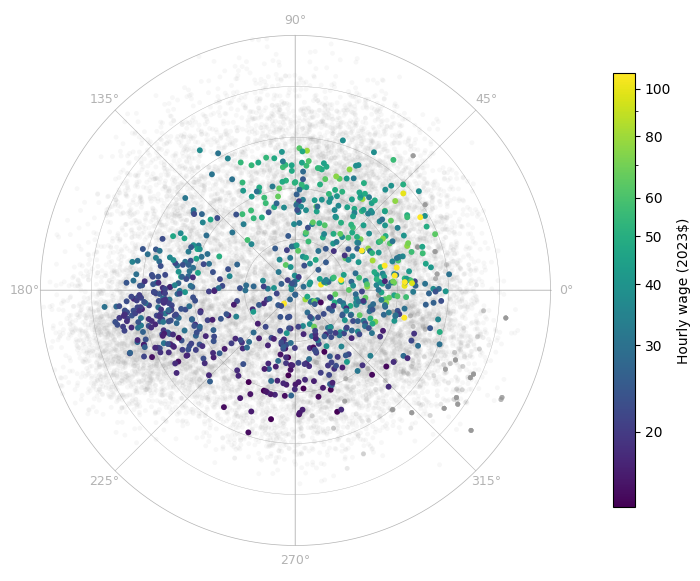

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import MaxNLocator, FuncFormatter

plt.close("all")

# --- checks ---
need = {"x_cart","y_cart","H_MEDIAN"}
miss = sorted(need - set(jobs_wage.columns))
if miss:
    raise ValueError(f"jobs_wage saknar kolumner: {miss}")
miss2 = sorted({"x_cart","y_cart"} - set(shock.columns))
if miss2:
    raise ValueError(f"shock saknar kolumner: {miss2}")

# --- figure ---
fig, ax = plt.subplots(figsize=(8, 8))
fig.patch.set_facecolor("white")

# --- frame (uses your main-fig add_polar_frame + GG_GREY) ---
add_polar_frame(
    ax,
    circle_color=GG_GREY["grey70"],
    spoke_color=GG_GREY["grey70"],
    label_color=GG_GREY["grey70"],
    cross_color=GG_GREY["grey70"],
    draw_labels=True,
    label_fs=9,
    label_r=1.06,
)

# --- background cloud ---
ax.scatter(
    shock["x_cart"], shock["y_cart"],
    s=12, alpha=0.08, c=GG_GREY["grey60"], edgecolors="none", zorder=1
)

# --- wage coloring: viridis + log10 transform, NO CLIPPING ---
vals_all = np.asarray(jobs_wage["H_MEDIAN"], float)
vals_pos = vals_all[np.isfinite(vals_all) & (vals_all > 0)]
if vals_pos.size < 10:
    raise ValueError("För få positiva H_MEDIAN-värden för log-skala.")

# same caps as your R code (but we won't clip/squish)
cap_hi = float(np.nanpercentile(vals_pos, 99))  # quantile(..., 0.99)
cap_lo = float(np.nanmin(vals_pos))             # min(...), must be >0

# trans="log10" equivalent
norm = mcolors.LogNorm(vmin=cap_lo, vmax=cap_hi, clip=False)

# set over/under colors explicitly so out-of-range isn't white
cmap = plt.get_cmap("viridis").copy()
cmap.set_over(cmap(1.0))
cmap.set_under(cmap(0.0))

sc = ax.scatter(
    jobs_wage["x_cart"], jobs_wage["y_cart"],
    c=vals_all,
    cmap=cmap,
    norm=norm,
    s=18,
    edgecolors="none",
    zorder=3
)

# --- axes ---
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
minimal_axes(ax)

from matplotlib.ticker import FuncFormatter

cbar = fig.colorbar(sc, ax=ax, fraction=0.035, pad=0.06, extend="neither")
cbar.set_label("Hourly wage (2023$)")

# choose human-friendly ticks within your range
ticks = [20, 30, 40, 50, 60, 80, 100]
ticks = [t for t in ticks if cap_lo <= t <= cap_hi]
cbar.set_ticks(ticks)

# force plain labels
cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(round(x))}"))
cbar.ax.yaxis.get_offset_text().set_visible(False)  # kill any ×10^k offset text

# --- save ---
out_fp = RP.exports / "wage_viridis_log10_noclip.pdf"
fig.savefig(out_fp, dpi=600, bbox_inches="tight", facecolor="white")
print("Saved:", out_fp)

plt.show()


In [8]:
import pandas as pd
import numpy as np

# --- 1) load excel ---
fp = "Education_onet.xlsx"  # change if needed
xl = pd.ExcelFile(fp)
print("Sheets:", xl.sheet_names)

# pick the first sheet by default (change if you want another)
sheet = xl.sheet_names[0]
df = pd.read_excel(fp, sheet_name=sheet)
print("Using sheet:", sheet)
print("Columns:", df.columns.tolist())
print(df.head(3))

Sheets: ['Education, Training, and Experi']
Using sheet: Education, Training, and Experi
Columns: ['O*NET-SOC Code', 'Title', 'Element ID', 'Element Name', 'Scale ID', 'Scale Name', 'Category', 'Data Value', 'N', 'Standard Error', 'Lower CI Bound', 'Upper CI Bound', 'Recommend Suppress', 'Date', 'Domain Source']
  O*NET-SOC Code             Title Element ID                 Element Name  \
0     11-1011.00  Chief Executives      2.D.1  Required Level of Education   
1     11-1011.00  Chief Executives      2.D.1  Required Level of Education   
2     11-1011.00  Chief Executives      2.D.1  Required Level of Education   

  Scale ID                                     Scale Name  Category  \
0       RL  Required Level Of Education (Categories 1-12)       1.0   
1       RL  Required Level Of Education (Categories 1-12)       2.0   
2       RL  Required Level Of Education (Categories 1-12)       3.0   

   Data Value   N  Standard Error  Lower CI Bound  Upper CI Bound  \
0        0.00  28  

In [18]:
# --- 2) map columns (tries common O*NET-style names) ---
col_code = next((c for c in df.columns if c.lower() in ["o*net-soc code","onet-soc code","onet_soc_code","soc code","soc_code"]), None)
col_elem = next((c for c in df.columns if c.lower() in ["element name","element_name","element"]), None)
col_lvl  = next((c for c in df.columns if c.lower() in ["category","scale value","level","education level","education_level","scale_value"]), None)
col_w    = next((c for c in df.columns if c.lower() in ["data value","data_value","value","percent","share","frequency","freq"]), None)

print("Detected:")
print(" code  =", col_code)
print(" elem  =", col_elem)
print(" level =", col_lvl)
print(" weight=", col_w)

need = [col_code, col_elem, col_lvl, col_w]
if any(v is None for v in need):
    raise ValueError("Couldn't auto-detect all needed columns. "
                     "Tell me df.columns.tolist() and I’ll map them exactly.")

# --- 3) filter to Required Level of Education ---
d = df.copy()
d[col_elem] = d[col_elem].astype(str).str.strip()
d = d[d[col_elem].eq("Required Level of Education")].copy()

# --- 4) coerce numeric + compute weighted mean per occupation ---
d[col_lvl] = pd.to_numeric(d[col_lvl], errors="coerce")
d[col_w]   = pd.to_numeric(d[col_w],   errors="coerce")
d = d.dropna(subset=[col_code, col_lvl, col_w])
d = d[(d[col_lvl] >= 1) & (d[col_lvl] <= 12) & (d[col_w] > 0)]

edu_occ = (
    d.groupby(col_code, as_index=False)
     .apply(lambda x: pd.Series({
         "RLE_weight_sum": float(x[col_w].sum()),
         "RLE_mean": float((x[col_lvl] * x[col_w]).sum() / x[col_w].sum())
     }))
     .reset_index(drop=True)
)

#rename the ONET column
edu_occ = edu_occ.rename(columns={"O*NET-SOC Code": "onet_code"})

print(edu_occ.head())
print("Occupations:", len(edu_occ))
print("RLE_mean range:", edu_occ["RLE_mean"].min(), "to", edu_occ["RLE_mean"].max())

Detected:
 code  = O*NET-SOC Code
 elem  = Element Name
 level = Category
 weight= Data Value
    onet_code  RLE_weight_sum  RLE_mean
0  11-1011.00           100.0    7.2413
1  11-1011.03           100.0    7.7037
2  11-1021.00           100.0    3.6732
3  11-2011.00           100.0    5.2070
4  11-2021.00           100.0    6.6805
Occupations: 878
RLE_mean range: 1.354 to 11.9167


In [31]:
#read jobs again (more observations now)
jobs_edu  = pd.read_csv(RP.exports / "occupation_embeddings_polar_scaled.csv")

jobs_edu  = ensure_cart(jobs_edu,  "jobs")

jobs_edu = jobs_edu.merge(edu_occ, on="onet_code", how="left")

Saved: /home/jonat/occupation-space/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_0/exports/education_required_level_mean.pdf


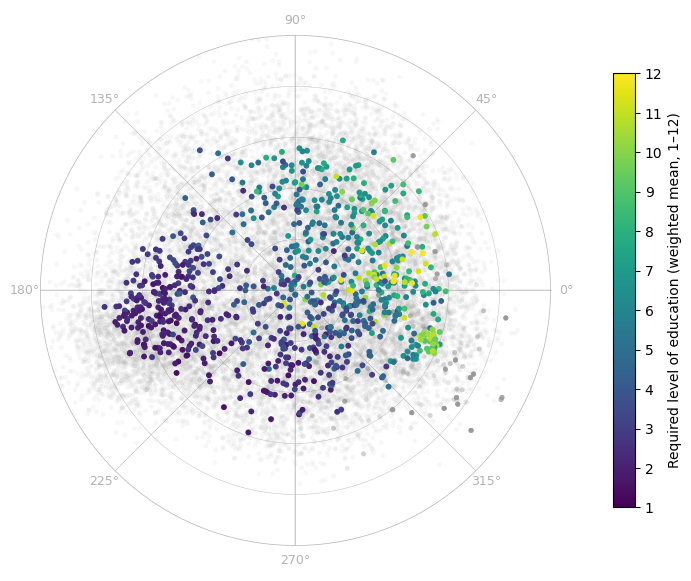

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import FuncFormatter

plt.close("all")

# --- checks ---
need = {"x_cart", "y_cart", "RLE_mean"}
miss = sorted(need - set(jobs_edu.columns))
if miss:
    raise ValueError(f"jobs_edu saknar kolumner: {miss}")
miss2 = sorted({"x_cart", "y_cart"} - set(shock.columns))
if miss2:
    raise ValueError(f"shock saknar kolumner: {miss2}")

# --- figure ---
fig, ax = plt.subplots(figsize=(8, 8))
fig.patch.set_facecolor("white")

# --- frame ---
add_polar_frame(
    ax,
    circle_color=GG_GREY["grey70"],
    spoke_color=GG_GREY["grey70"],
    label_color=GG_GREY["grey70"],
    cross_color=GG_GREY["grey70"],
    draw_labels=True,
    label_fs=9,
    label_r=1.06,
)

# --- background cloud ---
ax.scatter(
    shock["x_cart"], shock["y_cart"],
    s=12, alpha=0.08, c=GG_GREY["grey60"], edgecolors="none", zorder=1
)

# --- education coloring (linear 1–12) ---
vals = np.asarray(jobs_edu["RLE_mean"], float)
mask = np.isfinite(vals)

# keep the same cmap as wage for consistency
cmap = plt.get_cmap("viridis").copy()

# If you want fixed scale across figures:
norm = mcolors.Normalize(vmin=1, vmax=12, clip=False)

sc = ax.scatter(
    jobs_edu.loc[mask, "x_cart"],
    jobs_edu.loc[mask, "y_cart"],
    c=vals[mask],
    cmap=cmap,
    norm=norm,
    s=18,
    edgecolors="none",
    zorder=3
)

# --- axes ---
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
minimal_axes(ax)

# --- colorbar ---
cbar = fig.colorbar(sc, ax=ax, fraction=0.035, pad=0.06)
cbar.set_label("Required level of education (weighted mean, 1–12)")

ticks = list(range(1, 13))
cbar.set_ticks(ticks)
cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x)}"))
cbar.ax.yaxis.get_offset_text().set_visible(False)

# --- save ---
out_fp = RP.exports / "education_required_level_mean.pdf"
fig.savefig(out_fp, dpi=600, bbox_inches="tight", facecolor="white")
print("Saved:", out_fp)

plt.show()

Saved: /home/jonat/occupation-space/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_0/exports/panel_wage_education.pdf


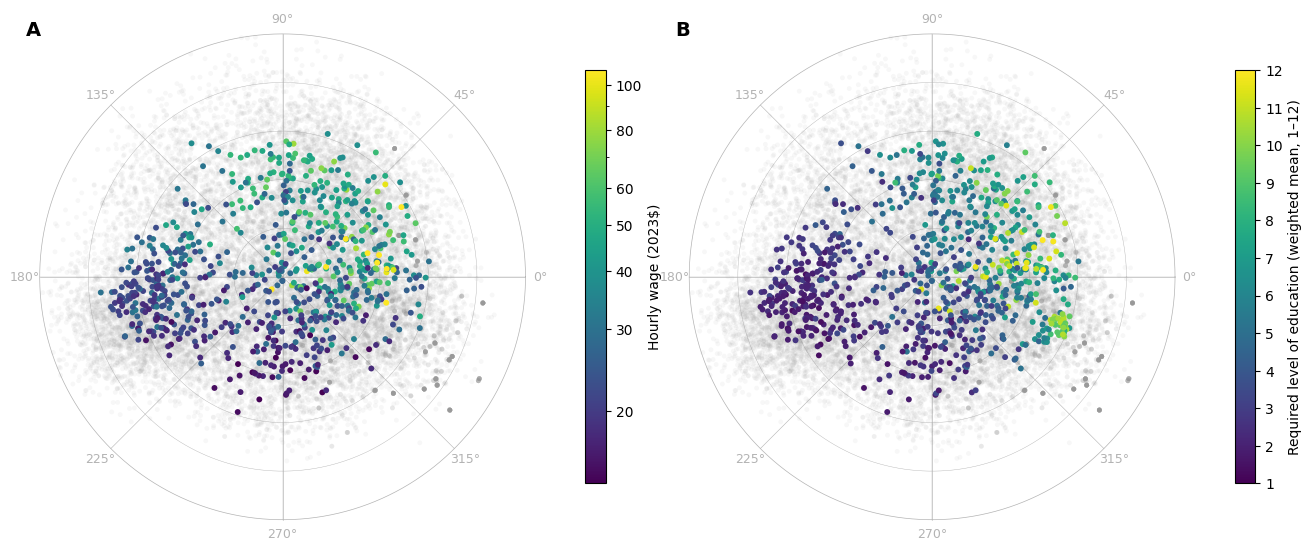

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import FuncFormatter

plt.close("all")

# --- checks ---
needA = {"x_cart", "y_cart", "H_MEDIAN"}
needB = {"x_cart", "y_cart", "RLE_mean"}
needS = {"x_cart", "y_cart"}

missA = sorted(needA - set(jobs_wage.columns))
missB = sorted(needB - set(jobs_edu.columns))
missS = sorted(needS - set(shock.columns))

if missA: raise ValueError(f"jobs_wage saknar kolumner: {missA}")
if missB: raise ValueError(f"jobs_edu saknar kolumner: {missB}")
if missS: raise ValueError(f"shock saknar kolumner: {missS}")

# --- helper: same base style as your single panels ---
def base_polar(ax):
    add_polar_frame(
        ax,
        circle_color=GG_GREY["grey70"],
        spoke_color=GG_GREY["grey70"],
        label_color=GG_GREY["grey70"],
        cross_color=GG_GREY["grey70"],
        draw_labels=True,
        label_fs=9,
        label_r=1.06,
    )
    ax.scatter(
        shock["x_cart"], shock["y_cart"],
        s=12, alpha=0.08, c=GG_GREY["grey60"], edgecolors="none", zorder=1
    )
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    minimal_axes(ax)

# --- figure: 2 panels ---
fig, (axA, axB) = plt.subplots(1, 2, figsize=(16, 8))
fig.patch.set_facecolor("white")

# =========================
# Panel A: wage (log scale)
# =========================
base_polar(axA)

vals_all = np.asarray(jobs_wage["H_MEDIAN"], float)
vals_pos = vals_all[np.isfinite(vals_all) & (vals_all > 0)]
if vals_pos.size < 10:
    raise ValueError("För få positiva H_MEDIAN-värden för log-skala.")

cap_hi = float(np.nanpercentile(vals_pos, 99))
cap_lo = float(np.nanmin(vals_pos))

norm_w = mcolors.LogNorm(vmin=cap_lo, vmax=cap_hi, clip=False)

cmap_w = plt.get_cmap("viridis").copy()
cmap_w.set_over(cmap_w(1.0))
cmap_w.set_under(cmap_w(0.0))

scA = axA.scatter(
    jobs_wage["x_cart"], jobs_wage["y_cart"],
    c=vals_all,
    cmap=cmap_w,
    norm=norm_w,
    s=18,
    edgecolors="none",
    zorder=3
)

cbarA = fig.colorbar(scA, ax=axA, fraction=0.035, pad=0.06, extend="neither")
cbarA.set_label("Hourly wage (2023$)")

ticksA = [20, 30, 40, 50, 60, 80, 100]
ticksA = [t for t in ticksA if cap_lo <= t <= cap_hi]
cbarA.set_ticks(ticksA)
cbarA.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(round(x))}"))
cbarA.ax.yaxis.get_offset_text().set_visible(False)

axA.text(0.02, 0.98, "A", transform=axA.transAxes, va="top", ha="left",
         fontsize=14, fontweight="bold")

# =========================
# Panel B: education (linear 1–12)
# =========================
base_polar(axB)

valsB = np.asarray(jobs_edu["RLE_mean"], float)
maskB = np.isfinite(valsB)

norm_e = mcolors.Normalize(vmin=1, vmax=12, clip=False)
cmap_e = plt.get_cmap("viridis").copy()

scB = axB.scatter(
    jobs_edu.loc[maskB, "x_cart"],
    jobs_edu.loc[maskB, "y_cart"],
    c=valsB[maskB],
    cmap=cmap_e,
    norm=norm_e,
    s=18,
    edgecolors="none",
    zorder=3
)

cbarB = fig.colorbar(scB, ax=axB, fraction=0.035, pad=0.06)
cbarB.set_label("Required level of education (weighted mean, 1–12)")
cbarB.set_ticks(list(range(1, 13)))
cbarB.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x)}"))
cbarB.ax.yaxis.get_offset_text().set_visible(False)

axB.text(0.02, 0.98, "B", transform=axB.transAxes, va="top", ha="left",
         fontsize=14, fontweight="bold")

# --- spacing + save ---
fig.subplots_adjust(wspace=0.10)

out_fp = RP.exports / "panel_wage_education.pdf"
fig.savefig(out_fp, dpi=600, bbox_inches="tight", facecolor="white")
print("Saved:", out_fp)

plt.show()

In [34]:
print(out_fp)

/home/jonat/occupation-space/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_0/exports/panel_wage_education.pdf
